In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import pandas as pd
import os

In [2]:
data_path = "C:/Users/seraf/fisica_computazionale/progetto_ising/codice_parallelo"

In [2]:
num_p = 8
magnetizzazione_df = pd.read_csv("./risultati_magnetizzazione/risultati_%dp.csv" %(num_p))

In [ ]:
L_values = np.array(magnetizzazione_df['L'].unique())
beta_values = np.array(magnetizzazione_df['beta'].unique())

In [ ]:
gruppi_L = magnetizzazione_df.groupby('L')

m = {}
err = {}

for L in L_values:
    # Salviamo l'intero array usando L come chiave
    m[L] = gruppi_L.get_group(L)['<M>'].values
    err[L] = gruppi_L.get_group(L)['errore su <M>'].values

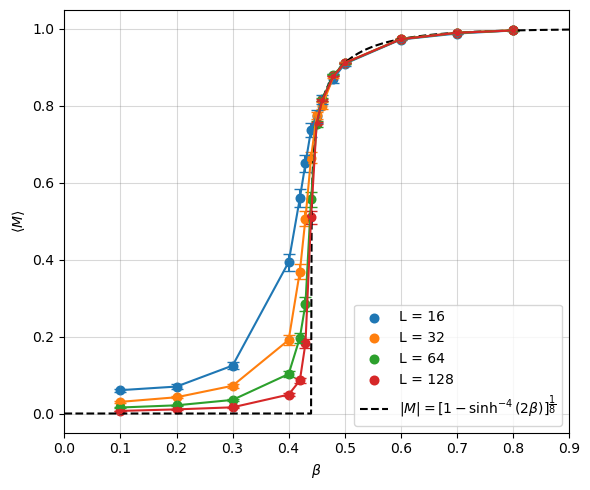

In [ ]:
def magnetizzazione_analitica(J=1.0):
    """
    Calcola la curva teorica della magnetizzazione spontanea per il modello di Ising 2D.
    
    Parametri:
    - J: Costante di accoppiamento (default 1.0)
    
    Ritorna:
    - beta: array numpy da 0 a 1 con passo 0.001
    - m_analitico: array numpy con i valori della magnetizzazione teorica
    """
    # Costruiamo l'array di beta da 0 a 1 a passi di 0.001
    # np.arange(start, stop, step) -> mettiamo 1.001 per includere l'1.0 finale
    beta = np.arange(0.0, 1.001, 0.001)
    
    # Inizializziamo il vettore analitico con tutti zeri
    m_analitico = np.zeros_like(beta)
    
    # Calcolo del beta critico teorico: beta_c = ln(1 + sqrt(2)) / (2J)
    beta_c = 0.5 * np.log(1 + np.sqrt(2)) / J
    
    # Creiamo una maschera booleana per selezionare solo i beta > beta_c
    # Al di sotto di beta_c (alta temperatura), la magnetizzazione spontanea è 0
    mask = beta > beta_c
    
    # Applichiamo la formula ESATTA solo nella regione ordinata (beta > beta_c)
    # Formula: m = (1 - (sinh(2 * beta * J))^-4)^(1/8)
    m_analitico[mask] = (1.0 - (np.sinh(2 * beta[mask] * J))**(-4))**(1/8)
    
    return beta, m_analitico

betas, m_analitico = magnetizzazione_analitica()

In [ ]:
plt.figure(figsize=(6, 5))
for L in L_values:
    plt.scatter(beta_values, m[L], linewidth=1.2, linestyle='-', label='L = %d' %(L))
    plt.errorbar(beta_values, m[L], yerr=err[L], marker='o', linestyle='-', markersize=3, capsize=4)

plt.plot(betas, m_analitico, c='black', linestyle='--', label=r"$|M| = \left[1 - \sinh^{-4}(2\beta)\right]^{\dfrac{1}{8}}$")
plt.xlabel(r'$\beta$')
plt.xlim(0, 0.9)
plt.ylabel(r'$\langle M \rangle$')
plt.legend(loc='lower right')
plt.grid(True, which='both', color='gray', alpha=0.3)
plt.tight_layout()

plt.savefig("./assets/transizione_di_fase.png")
plt.show()

Leggendo i dati da ./simulazioni/L_128/traiettoria_L_128_beta_0.800.txt...
Trovati 100 fotogrammi. Generazione della GIF in corso...


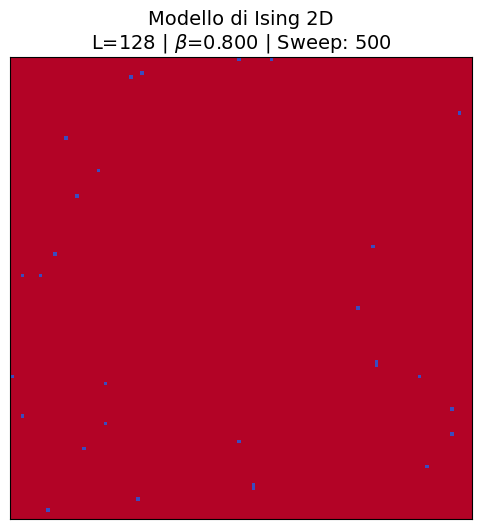

In [10]:
L_target=128
beta_target = 0.800

filename = ("./simulazioni/L_%d/traiettoria_L_%d_beta_%.3f.txt" %(L_target, L_target, beta_target))

frames = []
sweeps = []

print(f"Leggendo i dati da {filename}...")

# 3. Leggiamo il file e isoliamo solo i frame che ci interessano
with open(filename, 'r') as f:
    lines = f.readlines()

i = 0
while i < len(lines):
    line = lines[i].strip()
    # Cerchiamo l'intestazione del fotogramma
    if line.startswith("L:"):
        parts = line.split()
        L = int(parts[1])
        beta = float(parts[3])
        sweep = int(parts[5])
        
        i += 1 # Passiamo alla prima riga della matrice
        
        # Leggiamo la matrice L x L
        matrix = []
        for _ in range(L):
            row = [int(x) for x in lines[i].split()]
            matrix.append(row)
            i += 1
            
        # Se il frame corrisponde a L e Beta scelti, lo salviamo
        if L == L_target and abs(beta - beta_target) < 0.001:
            frames.append(np.array(matrix))
            sweeps.append(sweep)
    else:
        i += 1

if not frames:
    print("ERRORE: Nessun frame trovato per i parametri scelti. Controlla che L e Beta siano giusti!")
    exit()

print(f"Trovati {len(frames)} fotogrammi. Generazione della GIF in corso...")

# 4. Creiamo l'animazione
fig, ax = plt.subplots(figsize=(6, 6))

# Usiamo la colormap 'coolwarm' (Blu per gli spin -1, Rosso per gli spin +1)
cmap = plt.cm.coolwarm
matrice_plot = ax.imshow(frames[0], cmap=cmap, vmin=-1, vmax=1, interpolation='none')

# Togliamo i numeri dagli assi per renderlo più "pulito"
ax.set_xticks([])
ax.set_yticks([])
titolo = ax.set_title(f"Modello di Ising 2D\nL={L_target} | $\\beta$={beta_target:.3f} | Sweep: {sweeps[0]}", fontsize=14)

# Funzione che aggiorna il grafico a ogni fotogramma
def update(frame_idx):
    matrice_plot.set_data(frames[frame_idx])
    titolo.set_text(f"Modello di Ising 2D\nL={L_target} | $\\beta$={beta_target:.3f} | Sweep: {sweeps[frame_idx]}")
    return matrice_plot, titolo

# Creiamo l'oggetto animazione (intervallo di 100ms tra i frame)
ani = animation.FuncAnimation(fig, update, frames=len(frames), interval=100, blit=False)

ani.save('./assets/gif/ising_L%d_B%.3f.gif' %(L_target, beta_target), writer='pillow', fps=5)

Caricato correttamente: C:\Users\seraf\fisica_computazionale\progetto_ising\codice_parallelo\produzione_20260711_160811\tempi_speedup_1.csv
Caricato correttamente: C:\Users\seraf\fisica_computazionale\progetto_ising\codice_parallelo\produzione_20260711_160811\tempi_speedup_2.csv
Caricato correttamente: C:\Users\seraf\fisica_computazionale\progetto_ising\codice_parallelo\produzione_20260711_160811\tempi_speedup_4.csv
Caricato correttamente: C:\Users\seraf\fisica_computazionale\progetto_ising\codice_parallelo\produzione_20260711_160811\tempi_speedup_8.csv


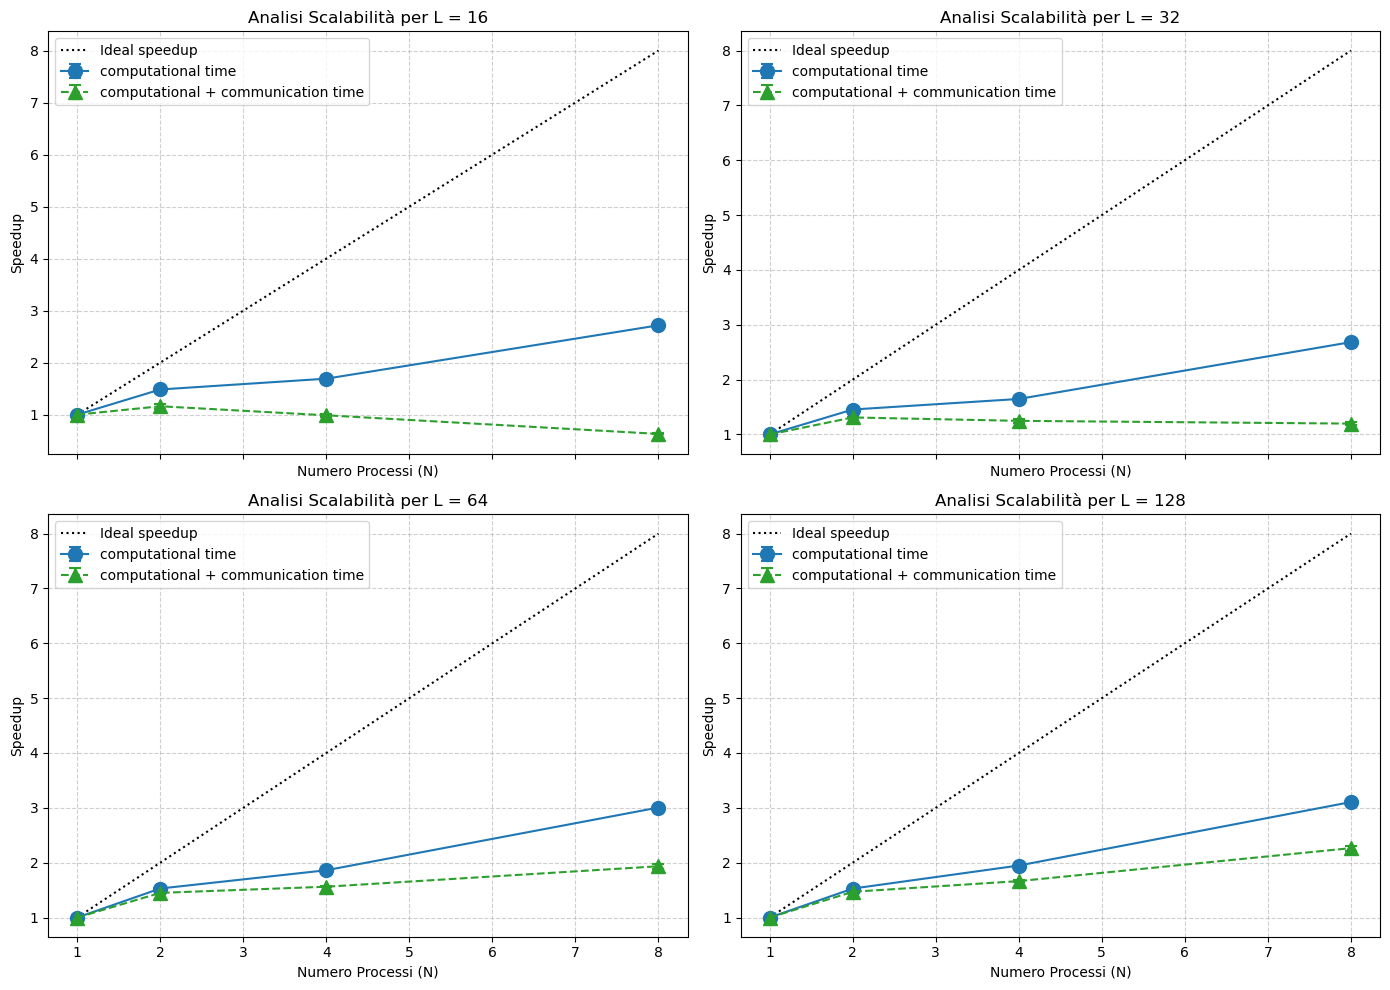

In [51]:
# Percorso assoluto ai dati
data_path = r"C:\Users\seraf\fisica_computazionale\progetto_ising\codice_parallelo\produzione_20260711_160811"

# Lista dei core testati
core_counts = [1, 2, 4, 8]
df_dict = {}

# 1. Caricamento robusto
for n in core_counts:
    filename = os.path.join(data_path, f"tempi_speedup_{n}.csv")
    if os.path.exists(filename):
        df = pd.read_csv(filename)
        
        # Creiamo subito la colonna algo_time (calcolo + comunicazione)
        if 'comm_time' in df.columns:
            df['algo_time'] = df['comp_time'] + df['comm_time']
        else:
            df['algo_time'] = df['comp_time'] # Fallback per file vecchi
            
        df_dict[n] = df
        print(f"Caricato correttamente: {filename}")
    else:
        print(f"ERRORE: File non trovato al percorso: {filename}")

# Recupero dati di riferimento (N=1)
if 1 not in df_dict:
    raise ValueError("Nessun file CSV per N=1 caricato! Controlla il percorso.")

df_base = df_dict[1]
L_values = sorted(df_base['L'].unique())

# 2. Setup Subplots
# Creiamo una griglia 2x2 per 4 taglie di L
fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True)
axes = axes.flatten() # Rendiamo l'array di assi monodimensionale per iterare facilmente

# 3. Ciclo di Plotting su Subplots
for i, L in enumerate(L_values):
    if i >= len(axes):
        break # Evita errori se abbiamo più di 4 L nel file
    
    ax = axes[i]
    
    # Estraiamo gli ARRAY grezzi (tutte le iterazioni) per N=1
    t1_comp_array = df_base[df_base['L'] == L]['comp_time'].values
    t1_algo_array = df_base[df_base['L'] == L]['algo_time'].values
    
    speedup_c = []
    speedup_c_err = []
    
    speedup_algo = []
    speedup_algo_err = []
    
    cores_found = []
    
    for n in core_counts:
        if n in df_dict and L in df_dict[n]['L'].values:
            df_n = df_dict[n]
            
            # Estraiamo gli ARRAY grezzi per N processori
            tn_comp_array = df_n[df_n['L'] == L]['comp_time'].values
            tn_algo_array = df_n[df_n['L'] == L]['algo_time'].values
            
            # Allineamento lunghezze (per sicurezza, nel caso in cui una run si sia interrotta a metà)
            min_len = min(len(t1_comp_array), len(tn_comp_array))
            t1_c_cut = t1_comp_array[:min_len]
            tn_c_cut = tn_comp_array[:min_len]
            
            t1_a_cut = t1_algo_array[:min_len]
            tn_a_cut = tn_algo_array[:min_len]
            
            # 1) Calcolo diretto degli ARRAY di speedup (divisione elemento per elemento)
            s_comp_array = t1_c_cut / tn_c_cut
            s_algo_array = t1_a_cut / tn_a_cut
            
            # 2) Calcolo media e deviazione standard empirica (ddof=1) direttamente sugli speedup
            speedup_c.append(np.mean(s_comp_array))
            speedup_c_err.append(np.std(s_comp_array, ddof=1) if min_len > 1 else 0.0)
            
            speedup_algo.append(np.mean(s_algo_array))
            speedup_algo_err.append(np.std(s_algo_array, ddof=1) if min_len > 1 else 0.0)
            
            cores_found.append(n)
    
    # Plot nel subplot specifico usando plt.errorbar
    ax.errorbar(cores_found, speedup_c, yerr=speedup_c_err, marker='o', markersize=10, color='tab:blue', 
                linestyle='-', label='computational time', capsize=4, capthick=1.5)
    
    ax.errorbar(cores_found, speedup_algo, yerr=speedup_algo_err, marker='^', markersize=10, color='tab:green', 
                linestyle='--', label='computational + communication time', capsize=4, capthick=1.5)
    
    ax.plot(core_counts, core_counts, 'k:', label='Ideal speedup', linewidth=1.5)
    
    ax.set_title(f'Analisi Scalabilità per L = {L}')
    ax.set_ylabel('Speedup')
    ax.set_xlabel('Numero Processi (N)')
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()

# Assicuriamoci che la cartella assets esista, se no la creiamo
os.makedirs("./assets", exist_ok=True)
plt.savefig("./assets/scaling_speedup.png")
plt.show()